# Event Impact Study — Alkame-Nifty50

Answers: do negative-sentiment events actually precede underperformance, and positive-sentiment
events outperformance? Uses `history_manager.py`'s real `get_events_for_symbol()`, paired with
forward price returns. This is original analysis mapping sentiment to price moves.

Data source: synthetic sample data from `../seed_sample_data.py`.
Switch `USE_SAMPLE_DATA = False` below once real events exist from `scheduler.py`.

In [1]:
import sys
import os
from pathlib import Path

# Repo root importable from inside notebooks/
sys.path.insert(0, str(Path.cwd().parent.parent))

import matplotlib.pyplot as plt
import pandas as pd

from config import NIFTY50_SYMBOLS, to_yfinance_ticker
from data_fetcher import DataFetcher
from history_manager import HistoryManager

# data_analyst/ importable too, for db_utils
sys.path.insert(0, str(Path.cwd().parent))
from db_utils import SAMPLE_DB_PATH  # noqa: E402

# Ensure figures folder exists
os.makedirs("../figures", exist_ok=True)

USE_SAMPLE_DATA = True  # flip to False once real events accumulate in the live DB
db_path = SAMPLE_DB_PATH if USE_SAMPLE_DATA else __import__("config").DB_PATH

history_manager = HistoryManager(db_path=db_path)
data_fetcher = DataFetcher()

FORWARD_WINDOW_HOURS = 6  # How far after an event to measure the price move

In [3]:
def compute_event_impact(symbol: str) -> pd.DataFrame:
    events = history_manager.get_events_for_symbol(symbol, limit=500)
    if not events:
        return pd.DataFrame()

    yf_ticker = to_yfinance_ticker(symbol)
    stock_df = data_fetcher.fetch_ohlcv(yf_ticker)
    if stock_df is None or stock_df.empty:
        return pd.DataFrame()

    # Get the exact timezone of the stock data (e.g., 'Asia/Kolkata')
    stock_tz = stock_df.index.tz

    rows = []
    for event in events:
        # 1. Parse timestamp as tz-naive
        event_time = pd.Timestamp(event.timestamp)
        
        # 2. Localize it to match the stock dataframe's timezone
        if stock_tz is not None and event_time.tz is None:
            event_time = event_time.tz_localize(stock_tz)
        elif stock_tz is not None and event_time.tz is not None:
            event_time = event_time.tz_convert(stock_tz)

        # Locate the price execution window (no-lookahead style alignment)
        after_event = stock_df.index[stock_df.index >= event_time]
        after_window = stock_df.index[stock_df.index >= event_time + pd.Timedelta(hours=FORWARD_WINDOW_HOURS)]
        
        if len(after_event) == 0 or len(after_window) == 0:
            continue  # event is too recent, or outside market data bounds

        price_at_event = stock_df.loc[after_event[0], "Close"]
        price_after_window = stock_df.loc[after_window[0], "Close"]
        forward_return_pct = (price_after_window - price_at_event) / price_at_event * 100.0

        rows.append({
            "symbol": symbol,
            "event_timestamp": event_time,
            "sentiment_score": event.sentiment_score,
            "headline": event.headline_or_label,
            "forward_return_pct": forward_return_pct,
        })

    return pd.DataFrame(rows)

# Match the first 15 symbols seeded by seed_sample_data.py
sample_symbols = NIFTY50_SYMBOLS[:15]  
all_impact_rows = []

for symbol in sample_symbols:
    impact_df = compute_event_impact(symbol)
    if not impact_df.empty:
        all_impact_rows.append(impact_df)
    print(f"  {symbol}: {len(impact_df)} events with a resolvable forward return")

impact_df = pd.concat(all_impact_rows, ignore_index=True) if all_impact_rows else pd.DataFrame()
print(f"\nTotal events with resolvable forward returns: {len(impact_df)}")
impact_df.head()

  RELIANCE: 20 events with a resolvable forward return
  HDFCBANK: 20 events with a resolvable forward return
  ICICIBANK: 20 events with a resolvable forward return
  INFY: 20 events with a resolvable forward return
  TCS: 20 events with a resolvable forward return
  BHARTIARTL: 20 events with a resolvable forward return
  SBIN: 20 events with a resolvable forward return
  LT: 20 events with a resolvable forward return
  ITC: 20 events with a resolvable forward return
  HINDUNILVR: 20 events with a resolvable forward return
  BAJFINANCE: 20 events with a resolvable forward return
  KOTAKBANK: 20 events with a resolvable forward return
  AXISBANK: 20 events with a resolvable forward return
  MARUTI: 20 events with a resolvable forward return
  SUNPHARMA: 20 events with a resolvable forward return

Total events with resolvable forward returns: 300


,symbol,event_timestamp,sentiment_score,headline,forward_return_pct
0,RELIANCE,2026-06-09 14:39:22.553653+05:30,0.299455,Sample headline #19 for RELIANCE (sentiment=0.30),1.961719
1,RELIANCE,2026-06-09 08:39:22.553653+05:30,0.731918,Sample headline #18 for RELIANCE (sentiment=0.73),-0.605399
2,RELIANCE,2026-06-09 02:39:22.553653+05:30,-0.067877,Sample headline #17 for RELIANCE (sentiment=-0...,0.000000
3,RELIANCE,2026-06-08 20:39:22.553653+05:30,0.579101,Sample headline #16 for RELIANCE (sentiment=0.58),0.000000
4,RELIANCE,2026-06-08 14:39:22.553653+05:30,-0.052314,Sample headline #15 for RELIANCE (sentiment=-0...,0.102318


## Does sentiment score actually predict the forward return?

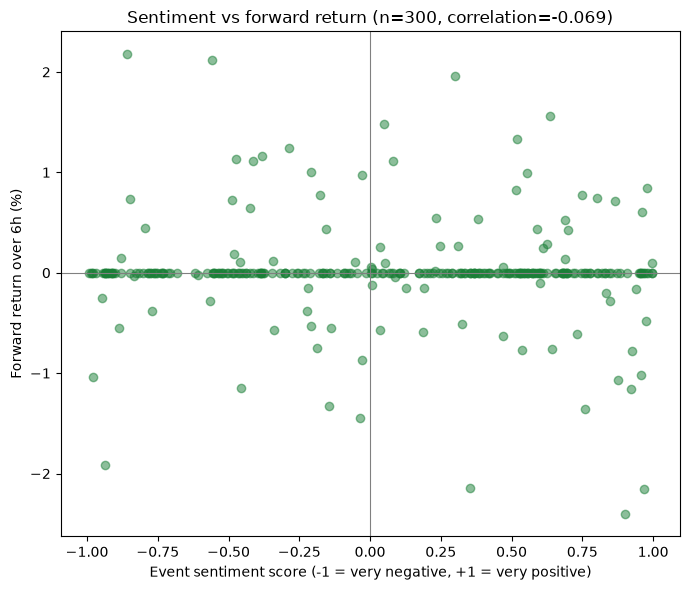

Sample size: 300
Correlation coefficient: -0.069


In [4]:
impact_df = impact_df.dropna(subset=["sentiment_score", "forward_return_pct"])
correlation = impact_df["sentiment_score"].corr(impact_df["forward_return_pct"])

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(impact_df["sentiment_score"], impact_df["forward_return_pct"], alpha=0.5, color="#1a7f37")
ax.axhline(0, color="gray", linewidth=0.8)
ax.axvline(0, color="gray", linewidth=0.8)
ax.set_xlabel("Event sentiment score (-1 = very negative, +1 = very positive)")
ax.set_ylabel(f"Forward return over {FORWARD_WINDOW_HOURS}h (%)")
ax.set_title(f"Sentiment vs forward return (n={len(impact_df)}, correlation={correlation:.3f})")
plt.tight_layout()
plt.savefig("../figures/event_impact_scatter.png", dpi=150)
plt.show()

print(f"Sample size: {len(impact_df)}")
print(f"Correlation coefficient: {correlation:.3f}")

In [5]:
impact_df["sentiment_bucket"] = pd.cut(
    impact_df["sentiment_score"], bins=[-1.01, -0.2, 0.2, 1.01],
    labels=["Negative", "Neutral", "Positive"],
)

bucket_summary = impact_df.groupby("sentiment_bucket", observed=True).agg(
    n_events=("forward_return_pct", "count"),
    mean_forward_return_pct=("forward_return_pct", "mean"),
    median_forward_return_pct=("forward_return_pct", "median"),
)
bucket_summary

,n_events,mean_forward_return_pct,median_forward_return_pct
sentiment_bucket,,,
Negative,108,0.053468,0.0
Neutral,51,-0.024235,0.0
Positive,141,-0.016904,0.0


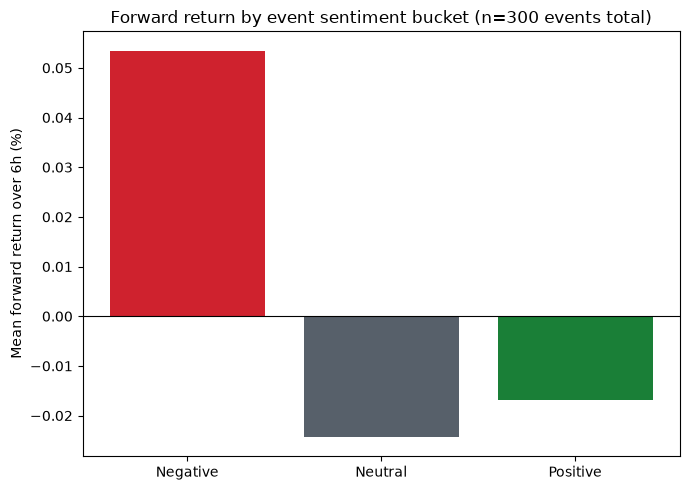

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
colors = {"Negative": "#cf222e", "Neutral": "#57606a", "Positive": "#1a7f37"}
bar_colors = [colors[str(b)] for b in bucket_summary.index]
ax.bar(bucket_summary.index.astype(str), bucket_summary["mean_forward_return_pct"], color=bar_colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel(f"Mean forward return over {FORWARD_WINDOW_HOURS}h (%)")
ax.set_title(f"Forward return by event sentiment bucket (n={len(impact_df)} events total)")
plt.tight_layout()
plt.savefig("../figures/event_impact_by_bucket.png", dpi=150)
plt.show()

## Findings

*(Summarize your read of the graphs and summary table here. Check if your correlation is strong or noisy, noting sample size limitations as a core analytical caveat.)*